<a href="https://colab.research.google.com/github/Ajay-Sankar-T/Agnirath-Strat/blob/main/Foundation-Visuals/Foundation_visualisations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FOUNDATION VISUALISATIONS**

## **1. Objective**

The goal of this section is to build **physical intuition** for a solar race car by modelling:

* Force and power requirements
* Solar energy input
* Battery degradation
* Energy balance across operating conditions

## **2. Key Visualisations & Insights**

## A. Forces & Power vs Velocity

### Model Used

The total mechanical power is governed by:

P = P_drag + P_rolling + P_climbing


Where:

* Drag $\propto (v^2)$ → Power $\propto (v^3)$
* Rolling resistance $\propto (v)$
* Climbing $\propto$ slope

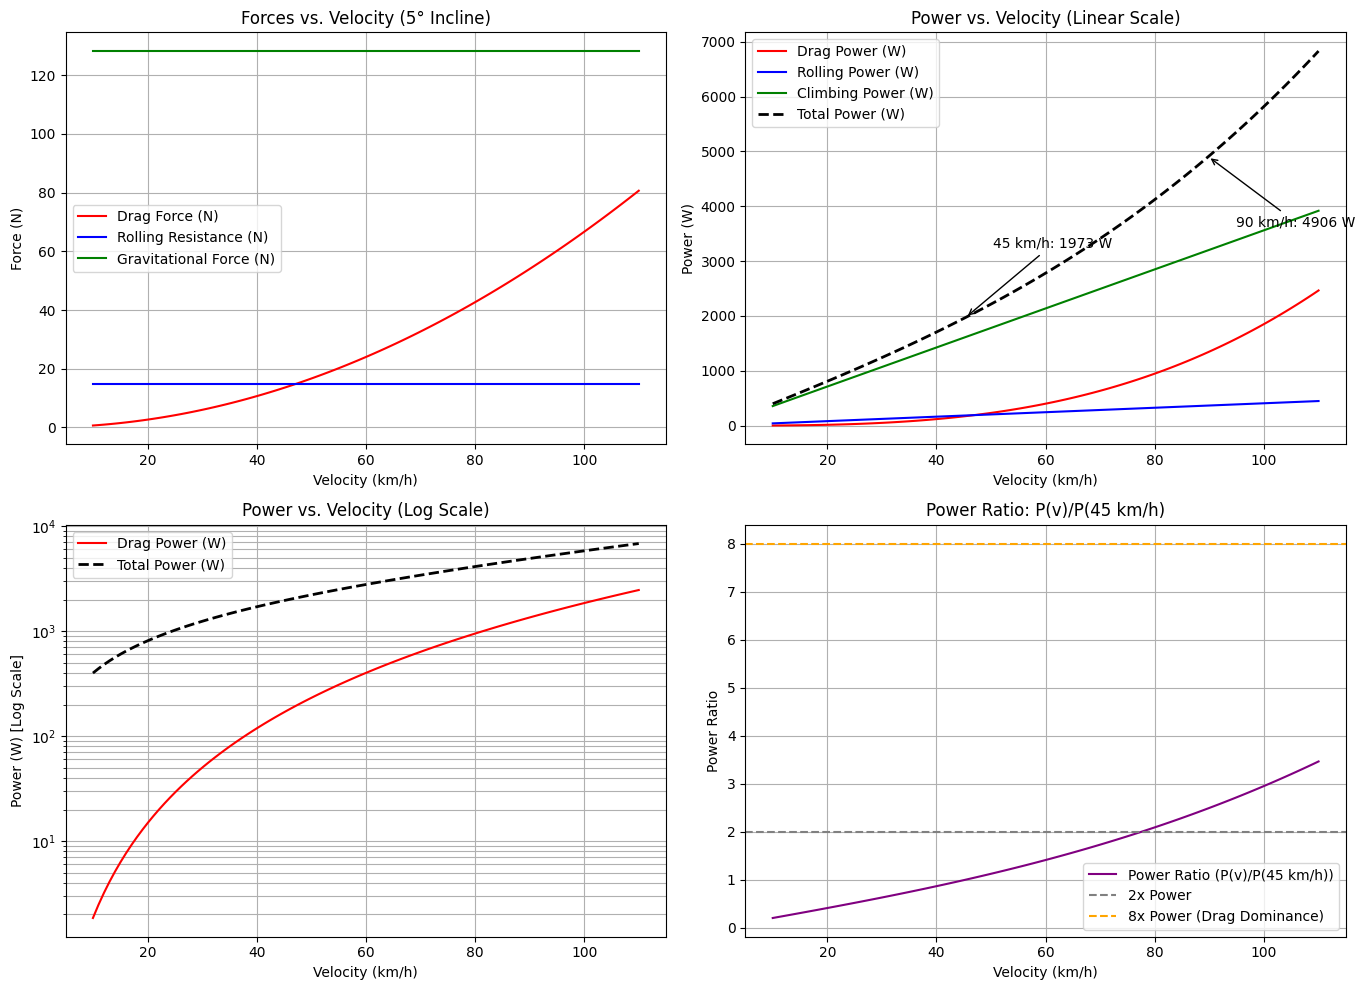

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_forces_and_power(
    velocity_kmh: float,
    incline_angle_deg: float = 5,
    car_mass_kg: float = 150,  # Lighter for solar cars
    drag_coefficient: float = 0.12,  # Optimized for solar cars
    frontal_area_m2: float = 1.2,
    rolling_resistance_coeff: float = 0.01,
    air_density_kg_m3: float = 1.2,
) -> dict:
    """
    Calculate forces (N) and power (W) for a solar car.
    """
    velocity_ms = velocity_kmh / 3.6
    incline_angle_rad = np.radians(incline_angle_deg)

    # Forces (N)
    drag_force = 0.5 * air_density_kg_m3 * drag_coefficient * frontal_area_m2 * velocity_ms**2
    rolling_resistance = rolling_resistance_coeff * car_mass_kg * 9.81 * np.cos(incline_angle_rad)
    gravitational_force = car_mass_kg * 9.81 * np.sin(incline_angle_rad)

    # Power (W)
    drag_power = drag_force * velocity_ms
    rolling_power = rolling_resistance * velocity_ms
    climbing_power = gravitational_force * velocity_ms
    total_power = drag_power + rolling_power + climbing_power

    return {
        "velocity_kmh": velocity_kmh,
        "forces_N": {
            "drag": drag_force,
            "rolling_resistance": rolling_resistance,
            "gravitational": gravitational_force,
        },
        "power_W": {
            "drag": drag_power,
            "rolling": rolling_power,
            "climbing": climbing_power,
            "total": total_power,
        },
    }

def plot_enhanced_graphs(velocities_kmh: list):
    """
    Plot enhanced graphs for forces and power vs. velocity.
    """
    # Initialize lists to store results
    forces = {key: [] for key in ["drag", "rolling_resistance", "gravitational"]}
    power = {key: [] for key in ["drag", "rolling", "climbing", "total"]}

    for v in velocities_kmh:
        result = calculate_forces_and_power(v)
        for key in forces:
            forces[key].append(result["forces_N"][key])
        for key in power:
            power[key].append(result["power_W"][key])

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Forces vs. Velocity ---
    ax = axes[0, 0]
    ax.plot(velocities_kmh, forces["drag"], label="Drag Force (N)", color="red")
    ax.plot(velocities_kmh, forces["rolling_resistance"], label="Rolling Resistance (N)", color="blue")
    ax.plot(velocities_kmh, forces["gravitational"], label="Gravitational Force (N)", color="green")
    ax.set_title("Forces vs. Velocity (5° Incline)")
    ax.set_xlabel("Velocity (km/h)")
    ax.set_ylabel("Force (N)")
    ax.legend()
    ax.grid(True)

    # --- Power vs. Velocity (Linear Scale) ---
    ax = axes[0, 1]
    ax.plot(velocities_kmh, power["drag"], label="Drag Power (W)", color="red")
    ax.plot(velocities_kmh, power["rolling"], label="Rolling Power (W)", color="blue")
    ax.plot(velocities_kmh, power["climbing"], label="Climbing Power (W)", color="green")
    ax.plot(velocities_kmh, power["total"], label="Total Power (W)", color="black", linestyle="--", linewidth=2)
    ax.set_title("Power vs. Velocity (Linear Scale)")
    ax.set_xlabel("Velocity (km/h)")
    ax.set_ylabel("Power (W)")
    ax.legend()
    ax.grid(True)

    # Annotate 45 km/h and 90 km/h on the linear power graph
    v45_idx = np.argmin(np.abs(np.array(velocities_kmh) - 45))
    v90_idx = np.argmin(np.abs(np.array(velocities_kmh) - 90))
    ax.annotate(
        f"45 km/h: {power['total'][v45_idx]:.0f} W",
        xy=(velocities_kmh[v45_idx], power["total"][v45_idx]),
        xytext=(20, 50),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
    )
    ax.annotate(
        f"90 km/h: {power['total'][v90_idx]:.0f} W",
        xy=(velocities_kmh[v90_idx], power["total"][v90_idx]),
        xytext=(20, -50),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
    )

    # --- Power vs. Velocity (Logarithmic Scale) ---
    ax = axes[1, 0]
    ax.plot(velocities_kmh, power["drag"], label="Drag Power (W)", color="red")
    ax.plot(velocities_kmh, power["total"], label="Total Power (W)", color="black", linestyle="--", linewidth=2)
    ax.set_yscale("log")  # Logarithmic scale for power
    ax.set_title("Power vs. Velocity (Log Scale)")
    ax.set_xlabel("Velocity (km/h)")
    ax.set_ylabel("Power (W) [Log Scale]")
    ax.legend()
    ax.grid(True, which="both")

    # --- Power Ratio: 90 km/h vs. 45 km/h ---
    ax = axes[1, 1]
    power_ratio = np.array(power["total"]) / power["total"][v45_idx]
    ax.plot(velocities_kmh, power_ratio, label="Power Ratio (P(v)/P(45 km/h))", color="purple")
    ax.axhline(y=2, color="gray", linestyle="--", label="2x Power")
    ax.axhline(y=8, color="orange", linestyle="--", label="8x Power (Drag Dominance)")
    ax.set_title("Power Ratio: P(v)/P(45 km/h)")
    ax.set_xlabel("Velocity (km/h)")
    ax.set_ylabel("Power Ratio")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

# Example: Plot for velocities from 10 km/h to 110 km/h
velocities_kmh = np.linspace(10, 110, 100)
plot_enhanced_graphs(velocities_kmh)

### 🔍 Key Observations

* At low speeds → **rolling resistance dominates**
* At high speeds → **aerodynamic drag dominates (v³ growth)**
* Power required increases **nonlinearly with speed**

---

### 🔥 Critical Insight

> Doubling speed results in ~8× increase in drag power, making high-speed cruising extremely energy expensive.

## 🔹 B. Solar Power Model

### Model

P_solar = (DNI cosθ + DHI) ⋅ A η

In [ ]:
import math

def calculate_solar_power(
    dni: float,
    dhi: float,
    panel_efficiency: float,
    panel_area: float,
    sun_angle_deg: float,
    panel_tilt_deg: float = 0,
) -> float:
    """
    Calculate solar power (W) for a flat or tilted panel.

    Args:
        dni: Direct Normal Irradiance (W/m²).
        dhi: Diffuse Horizontal Irradiance (W/m²).
        panel_efficiency: Efficiency of the solar panel (0-1).
        panel_area: Area of the panel (m²).
        sun_angle_deg: Angle of the sun above the horizon (degrees).
        panel_tilt_deg: Tilt angle of the panel (0 = flat, 90 = vertical).

    Returns:
        Solar power in watts (W).
    """
    sun_angle_rad = math.radians(sun_angle_deg)
    panel_tilt_rad = math.radians(panel_tilt_deg)

    # Angle of incidence (simplified for flat or tilted panels)
    if panel_tilt_deg == 0:
        # Flat panel: cos(theta) = sin(sun_angle)
        cos_theta = math.sin(sun_angle_rad)
    else:
        # Tilted panel: cos(theta) = cos(sun_angle - panel_tilt)
        cos_theta = max(0, math.cos(sun_angle_rad - panel_tilt_rad))

    # Global Tilted Irradiance (simplified)
    gti = dni * cos_theta + dhi

    # Solar power
    solar_power = gti * panel_area * panel_efficiency
    return solar_power

# Example usage
dni_clear = 800  # W/m²
dhi_clear = 100  # W/m²
dni_cloudy = 50  # W/m²
dhi_cloudy = 400  # W/m²

power_clear = calculate_solar_power(dni_clear, dhi_clear, 0.22, 4, 30)
power_cloudy = calculate_solar_power(dni_cloudy, dhi_cloudy, 0.22, 4, 30)

print(f"Solar power (clear sky): {power_clear:.1f} W")
print(f"Solar power (cloudy): {power_cloudy:.1f} W")

Solar power (clear sky): 440.0 W
Solar power (cloudy): 374.0 W


### 🔍 Observations

* Clear sky → high DNI → strong power
* Cloudy → diffuse dominates → lower efficiency
* Panel angle significantly affects output

---

### 🔥 Insight

> Solar input is highly variable and introduces **uncertainty into energy planning**.

## 🔹 C. Battery Degradation

### Model

* SOH decays exponentially with cycles
* Temperature accelerates degradation

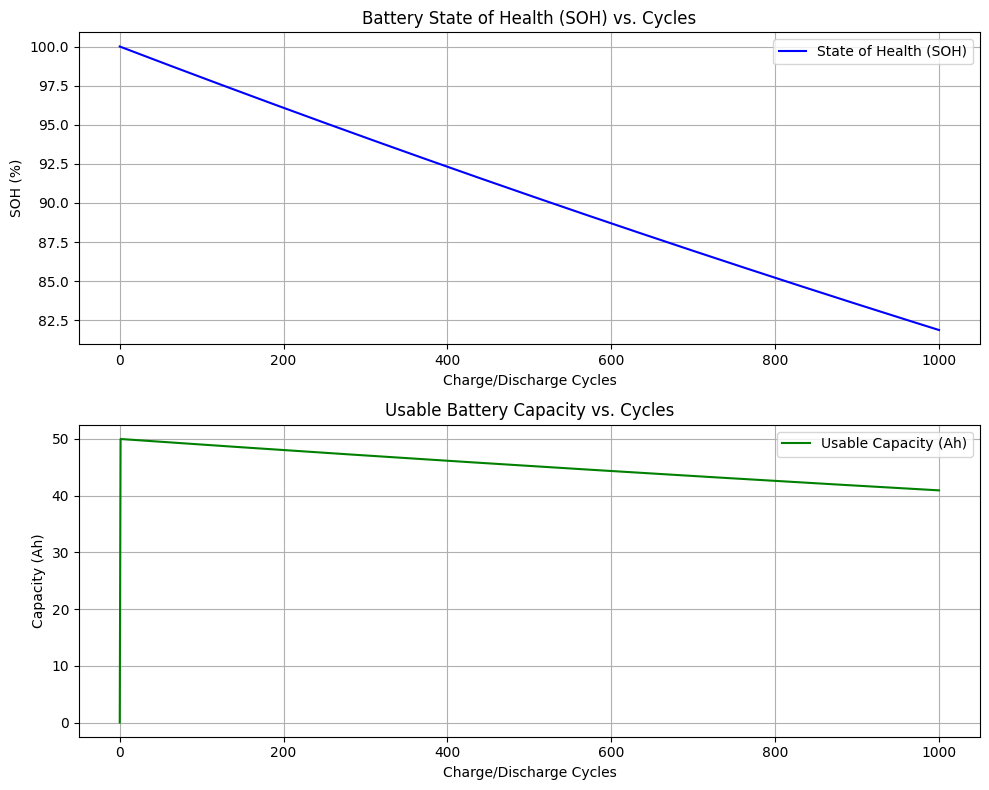

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_battery_degradation(
    initial_capacity_ah: float = 50,
    cycles: int = 1000,
    soh_loss_per_cycle: float = 0.0002,  # 0.02% loss per cycle (typical for Li-ion)
    temperature_effect: float = 1.0,    # Multiplier for temp (1.0 = 25°C, >1 = hot, <1 = cold)
) -> dict:
    """
    Simulate battery degradation over charge/discharge cycles.

    Args:
        initial_capacity_ah: Original battery capacity in Ah.
        cycles: Number of charge/discharge cycles to simulate.
        soh_loss_per_cycle: Fraction of SOH lost per cycle.
        temperature_effect: Multiplier for degradation rate (higher = faster aging).

    Returns:
        Dictionary with SOH and usable capacity over cycles.
    """
    soh = np.ones(cycles + 1)  # SOH starts at 100% (1.0)
    usable_capacity = np.zeros(cycles + 1)

    for i in range(1, cycles + 1):
        soh[i] = soh[i-1] * (1 - soh_loss_per_cycle * temperature_effect)
        usable_capacity[i] = initial_capacity_ah * soh[i]

    return {
        "cycles": np.arange(cycles + 1),
        "soh": soh,
        "usable_capacity_ah": usable_capacity,
    }

def plot_degradation(results: dict):
    """
    Plot SOH and usable capacity vs. cycles.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # SOH vs. Cycles
    ax1.plot(results["cycles"], results["soh"] * 100, label="State of Health (SOH)", color="blue")
    ax1.set_title("Battery State of Health (SOH) vs. Cycles")
    ax1.set_xlabel("Charge/Discharge Cycles")
    ax1.set_ylabel("SOH (%)")
    ax1.grid(True)
    ax1.legend()

    # Usable Capacity vs. Cycles
    ax2.plot(results["cycles"], results["usable_capacity_ah"], label="Usable Capacity (Ah)", color="green")
    ax2.set_title("Usable Battery Capacity vs. Cycles")
    ax2.set_xlabel("Charge/Discharge Cycles")
    ax2.set_ylabel("Capacity (Ah)")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Example: Simulate 1000 cycles
results = simulate_battery_degradation(initial_capacity_ah=50, cycles=1000)
plot_degradation(results)

### 🔍 Observations

* Capacity gradually decreases over time
* Effective energy budget reduces

---

### 🔥 Insight

> Strategy must consider **long-term degradation**, not just instantaneous energy.

## 🔹 D. Energy Balance Simulation

### Core Equation

Energy In = Battery + Solar
Energy Out = Mechanical + Losses


In [ ]:
def simulate_race_energy(
    distance_km: float = 1000,
    avg_speed_kmh: float = 60,
    solar_power_w: float = 500,  # Average solar input
    motor_power_w: float = 1000, # Average motor power
    initial_capacity_ah: float = 50,
    voltage_v: float = 48,       # Battery voltage
    soh: float = 0.9,            # Current SOH (e.g., 90%)
) -> dict:
    """
    Simulate energy balance over a race, accounting for battery degradation.

    Args:
        distance_km: Total race distance.
        avg_speed_kmh: Average speed.
        solar_power_w: Average solar power input.
        motor_power_w: Average motor power.
        initial_capacity_ah: Battery capacity at 100% SOH.
        voltage_v: Battery voltage.
        soh: Current State of Health (0-1).

    Returns:
        Dictionary with energy balance and SOC over time.
    """
    # Usable capacity (Ah)
    usable_capacity_ah = initial_capacity_ah * soh
    total_energy_wh = usable_capacity_ah * voltage_v

    # Time to complete race (hours)
    time_h = distance_km / avg_speed_kmh

    # Energy consumed (Wh)
    energy_consumed_wh = motor_power_w * time_h

    # Energy from solar (Wh)
    energy_solar_wh = solar_power_w * time_h

    # Net energy (Wh)
    net_energy_wh = energy_solar_wh - energy_consumed_wh

    # Final SOC (%)
    final_soc = (total_energy_wh + net_energy_wh) / (initial_capacity_ah * voltage_v) * 100

    return {
        "distance_km": distance_km,
        "time_h": time_h,
        "energy_consumed_wh": energy_consumed_wh,
        "energy_solar_wh": energy_solar_wh,
        "net_energy_wh": net_energy_wh,
        "initial_soc": 100,  # Assume starting at 100%
        "final_soc": max(0, min(100, final_soc)),  # Clamp to 0-100%
        "usable_capacity_ah": usable_capacity_ah,
    }

# Example: Simulate a 1000 km race
results = simulate_race_energy(
    distance_km=1000,
    avg_speed_kmh=60,
    solar_power_w=500,
    motor_power_w=1000,
    initial_capacity_ah=50,
    soh=0.9,
)
print(f"Final SOC: {results['final_soc']:.1f}%")
print(f"Net Energy: {results['net_energy_wh']:.1f} Wh")

Final SOC: 0.0%
Net Energy: -8333.3 Wh


### 🔥 Insight

> Racing strategy is fundamentally an **energy budgeting problem over time**.

---

# **3. Overall Engineering Insights**

---

## ✅ 1. Speed is the biggest enemy

* Drag grows as $(v^3)$
* Small speed increases → huge energy penalty

## ✅ 2. Energy is not conserved (practically)

* Losses in:

  * motor
  * inverter
  * regen
* Leads to irreversible energy loss

## ✅ 3. Solar input is uncertain

* Must plan for variability
* Cannot rely on constant input

## ✅ 4. Optimal driving ≠ maximum speed

* Must balance:

  * energy consumption
  * solar generation
  * battery limits

---

# **4. Final Conclusion**

> The visualisations demonstrate that solar car strategy is governed by nonlinear physics, irreversible losses, and uncertain energy input. Efficient racing therefore requires careful optimization of velocity, energy usage, and environmental adaptation rather than naive high-speed driving.

In [ ]:
def simulate_hill_cycle(
    hill_height_m: float = 100,
    car_mass_kg: float = 200,
    motor_efficiency: float = 0.9,
    regen_efficiency: float = 0.7,
    g: float = 9.81,
) -> dict:
    """
    Simulate energy loss in an uphill-downhill cycle.

    Args:
        hill_height_m: Height of the hill (m).
        car_mass_kg: Mass of the car (kg).
        motor_efficiency: Motor efficiency (0-1).
        regen_efficiency: Regen braking efficiency (0-1).
        g: Gravitational acceleration (m/s²).

    Returns:
        Dictionary with energy calculations.
    """
    # Potential energy to climb the hill (J)
    potential_energy_j = car_mass_kg * g * hill_height_m

    # Energy from battery to climb uphill (J)
    energy_uphill_j = potential_energy_j / motor_efficiency

    # Energy recovered downhill (J)
    energy_regen_j = potential_energy_j * regen_efficiency

    # Net energy loss (J)
    net_energy_loss_j = energy_uphill_j - energy_regen_j

    # Round-trip efficiency
    round_trip_efficiency = motor_efficiency * regen_efficiency

    return {
        "potential_energy_j": potential_energy_j,
        "energy_uphill_j": energy_uphill_j,
        "energy_regen_j": energy_regen_j,
        "net_energy_loss_j": net_energy_loss_j,
        "round_trip_efficiency": round_trip_efficiency,
    }

# Example: Simulate a 100-meter hill
results = simulate_hill_cycle(hill_height_m=100)
print(f"Potential Energy: {results['potential_energy_j']:.1f} J")
print(f"Energy Uphill: {results['energy_uphill_j']:.1f} J")
print(f"Energy Regen: {results['energy_regen_j']:.1f} J")
print(f"Net Energy Loss: {results['net_energy_loss_j']:.1f} J")
print(f"Round-Trip Efficiency: {results['round_trip_efficiency'] * 100:.1f}%")

Potential Energy: 196200.0 J
Energy Uphill: 218000.0 J
Energy Regen: 137340.0 J
Net Energy Loss: 80660.0 J
Round-Trip Efficiency: 63.0%


### 🔍 Observation

* Energy recovered < energy spent
* Net loss always occurs

---

### 🔥 Insight

> Regenerative braking is **not lossless**, which directly explains why:

* Constant speed strategies can outperform “coast & recover”

## 🔹 F. Race Energy Simulation

### Observations

* Final SOC depends on:

  * Speed
  * Solar input
  * Battery SOH

In [ ]:
import numpy as np

def power_balance_complete(
    soc_rate: float,  # Rate of change of SOC per second (negative for discharge)
    velocity_kmh: float,
    acceleration_ms2: float,
    incline_angle_deg: float,
    dni: float,
    dhi: float,
    panel_area: float,
    panel_efficiency: float,
    car_mass_kg: float,
    drag_coefficient: float,
    frontal_area_m2: float,
    rolling_resistance_coeff: float,
    motor_efficiency: float,
    regen_efficiency: float,
    battery_voltage: float = 48,
    rated_capacity_ah: float = 50,
    soh: float = 0.9,
    inverter_losses_w: float = 20,
    heat_losses_w: float = 30,
    auxiliary_power_w: float = 50,
    air_density_kg_m3: float = 1.2,
) -> dict:
    """
    Calculate the complete power balance for a solar car, including SOC/SOH dynamics.
    """
    velocity_ms = velocity_kmh / 3.6
    incline_angle_rad = np.radians(incline_angle_deg)

    # --- Battery Power ---
    usable_capacity_ah = rated_capacity_ah * soh
    battery_current = -usable_capacity_ah * soc_rate  # Negative SOC rate implies positive current (discharge)
    battery_power = battery_voltage * battery_current

    # --- Solar Power ---
    solar_power = (dni * np.cos(incline_angle_rad) + dhi) * panel_area * panel_efficiency

    # --- Forces (N) ---
    drag_force = 0.5 * air_density_kg_m3 * drag_coefficient * frontal_area_m2 * velocity_ms**2
    rolling_resistance = rolling_resistance_coeff * car_mass_kg * 9.81 * np.cos(incline_angle_rad)
    gravitational_force = car_mass_kg * 9.81 * np.sin(incline_angle_rad)
    total_force = drag_force + rolling_resistance + gravitational_force

    # --- Mechanical Power (W) ---
    mechanical_power = (car_mass_kg * acceleration_ms2 * velocity_ms) + (total_force * velocity_ms)

    # --- Power Balance ---
    left_side = battery_power + solar_power
    right_side = ((1/motor_efficiency) - regen_efficiency) * mechanical_power + inverter_losses_w + heat_losses_w + auxiliary_power_w

    return {
        "battery_power_w": battery_power,
        "solar_power_w": solar_power,
        "mechanical_power_w": mechanical_power,
        "left_side_w": left_side,
        "right_side_w": right_side,
        "balance_w": left_side - right_side,
        "state": "Energy Positive" if (left_side - right_side) > 0 else
                 "Energy Neutral" if abs(left_side - right_side) < 10 else
                 "Energy Negative",
    }

# Example usage
results = power_balance_complete(
    soc_rate=-0.01,  # 1% SOC decrease per second
    velocity_kmh=60,
    acceleration_ms2=0.5,
    incline_angle_deg=0,
    dni=800,
    dhi=100,
    panel_area=4,
    panel_efficiency=0.22,
    car_mass_kg=200,
    drag_coefficient=0.15,
    frontal_area_m2=1.5,
    rolling_resistance_coeff=0.02,
    motor_efficiency=0.9,
    regen_efficiency=0.7,
)
print(f"Battery Power: {results['battery_power_w']:.1f} W")
print(f"Solar Power: {results['solar_power_w']:.1f} W")
print(f"Mechanical Power: {results['mechanical_power_w']:.1f} W")
print(f"Left Side (In-Flux): {results['left_side_w']:.1f} W")
print(f"Right Side (Out-Flux): {results['right_side_w']:.1f} W")
print(f"Balance: {results['balance_w']:.1f} W")
print(f"State: {results['state']}")

Battery Power: 21.6 W
Solar Power: 792.0 W
Mechanical Power: 2945.7 W
Left Side (In-Flux): 813.6 W
Right Side (Out-Flux): 1311.0 W
Balance: -497.4 W
State: Energy Negative


### 🔍 Observations

* At low speeds → energy positive possible
* At high speeds → always energy negative
* There exists a **critical speed threshold**

---

### 🔥 Insight

> The car operates in three regimes:

* **Energy Positive** → charging
* **Energy Neutral** → sustainable
* **Energy Negative** → draining

## 🔹 E. Hill Cycle Efficiency

### Result

\[
\text{Round-trip efficiency} = \eta_{\text{motor}} \times \eta_{\text{regen}}
\]

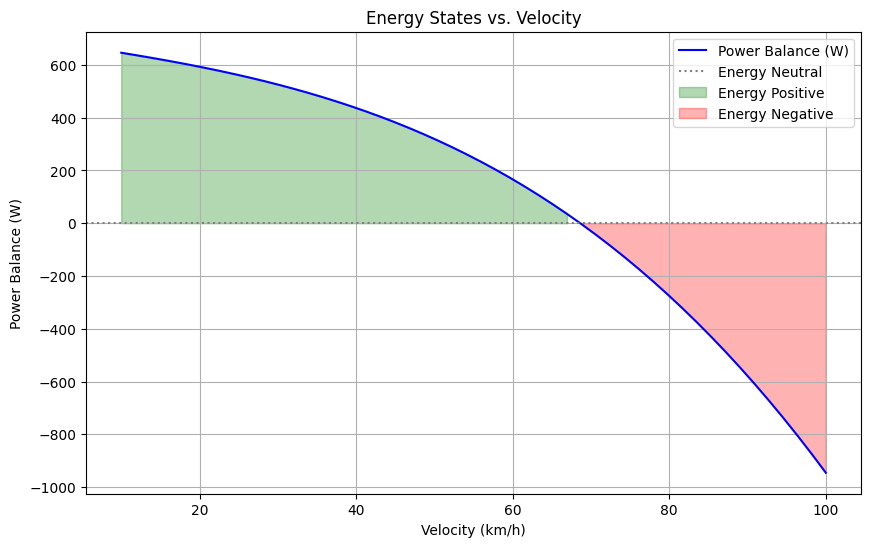

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_energy_states(
    velocities_kmh: list,
    acceleration_ms2: float = 0,
    incline_angle_deg: float = 0,
    dni: float = 800,
    dhi: float = 100,
    panel_area: float = 4,
    panel_efficiency: float = 0.22,
    car_mass_kg: float = 200,
    drag_coefficient: float = 0.15,
    frontal_area_m2: float = 1.5,
    rolling_resistance_coeff: float = 0.02,
    motor_efficiency: float = 0.9,
    regen_efficiency: float = 0.7,
    battery_voltage: float = 48,
    rated_capacity_ah: float = 50,
    soh: float = 0.9,
    inverter_losses_w: float = 20,
    heat_losses_w: float = 30,
    auxiliary_power_w: float = 50,
    air_density_kg_m3: float = 1.2,
) -> dict:
    """
    Analyze energy states across a range of velocities.
    """
    results = []
    for velocity_kmh in velocities_kmh:
        velocity_ms = velocity_kmh / 3.6
        incline_angle_rad = np.radians(incline_angle_deg)

        # --- Solar Power ---
        solar_power = (dni * np.cos(incline_angle_rad) + dhi) * panel_area * panel_efficiency

        # --- Forces (N) ---
        drag_force = 0.5 * air_density_kg_m3 * drag_coefficient * frontal_area_m2 * velocity_ms**2
        rolling_resistance = rolling_resistance_coeff * car_mass_kg * 9.81 * np.cos(incline_angle_rad)
        gravitational_force = car_mass_kg * 9.81 * np.sin(incline_angle_rad)
        total_force = drag_force + rolling_resistance + gravitational_force

        # --- Mechanical Power (W) ---
        mechanical_power = (car_mass_kg * acceleration_ms2 * velocity_ms) + (total_force * velocity_ms)

        # --- Power Balance ---
        left_side = solar_power  # Assume no battery discharge/charge for this analysis (focus on solar vs. mechanical)
        right_side = ((1/motor_efficiency) - regen_efficiency) * mechanical_power + inverter_losses_w + heat_losses_w + auxiliary_power_w

        # --- Energy State ---
        balance = left_side - right_side
        state = "Energy Positive" if balance > 0 else "Energy Neutral" if abs(balance) < 10 else "Energy Negative"

        results.append({
            "velocity_kmh": velocity_kmh,
            "solar_power_w": solar_power,
            "mechanical_power_w": mechanical_power,
            "left_side_w": left_side,
            "right_side_w": right_side,
            "balance_w": balance,
            "state": state,
        })

    return results

def plot_energy_states(results: list):
    """
    Plot energy states vs. velocity.
    """
    velocities = [r["velocity_kmh"] for r in results]
    states = [r["state"] for r in results]
    balance = [r["balance_w"] for r in results]

    plt.figure(figsize=(10, 6))
    plt.plot(velocities, balance, label="Power Balance (W)", color="blue")
    plt.axhline(y=0, color="gray", linestyle=":", label="Energy Neutral")
    plt.fill_between(velocities, balance, 0, where=[b > 0 for b in balance], color="green", alpha=0.3, label="Energy Positive")
    plt.fill_between(velocities, balance, 0, where=[b < 0 for b in balance], color="red", alpha=0.3, label="Energy Negative")
    plt.title("Energy States vs. Velocity")
    plt.xlabel("Velocity (km/h)")
    plt.ylabel("Power Balance (W)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: Analyze energy states for velocities from 10 km/h to 100 km/h
velocities_kmh = np.linspace(10, 100, 50)
results = analyze_energy_states(velocities_kmh)
plot_energy_states(results)


### 🔍 Observations

* At low speeds → energy positive possible
* At high speeds → always energy negative
* There exists a **critical speed threshold**

---

### 🔥 Insight

> The car operates in three regimes:

* **Energy Positive** → charging
* **Energy Neutral** → sustainable
* **Energy Negative** → draining